In [ ]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')
print("--- Columns aur Data ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Columns aur Data ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

--- Missing Values ---
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("spam.csv", encoding='latin-1')

df = df.iloc[:, [0, 1]] 

df.columns = ['Label', 'SMS']

df['SMS'] = df['SMS'].fillna('').astype(str)
df['Label'] = df['Label'].str.strip().str.lower()

print(f"Dataset Loaded Successfully! Total Rows: {len(df)}")
print(df['Label'].value_counts())

X = df['SMS']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', lowercase=True)),
    ('nb', MultinomialNB())
])

print("\nTraining Model...")
pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

print("\n FINAL RESULTS ")
print("Test Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


sample = ["Conetests! ye code chal gya, click link to win gold.", "bhai project ban gaya kya? Update de."]
print("\nLive Checking Samples:")
for sms, p in zip(sample, pipeline.predict(sample)):
    print(f"[{p.upper()}] -> {sms}")

Dataset Loaded Successfully! Total Rows: 5572
Label
ham     4825
spam     747
Name: count, dtype: int64

Training Model...

================ FINAL RESULTS ================
Test Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Live Checking Samples:
[SPAM] -> Conetests! ye code chal gya, click link to win gold.
[HAM] -> bhai project ban gaya kya? Update de.


Confusion Matrix:
 [[965   0]
 [ 37 113]]


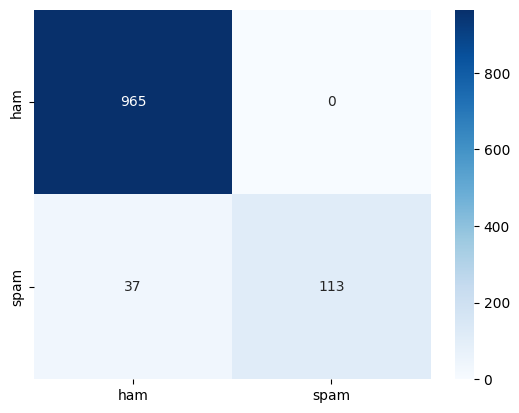

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.show()